In [12]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import seaborn as sns

escape

In [13]:
# load data
# WT_escape_angle = pd.read_csv('extract_escape_WT_labeled.csv')
WT_escape_angle = pd.read_csv('extract_escape_WT_labeled+motion_mode_data.csv')

In [14]:
# prepare copy for last_switch analysis
WT_escape_angle_last_switch = WT_escape_angle.copy()
# remove row if last_switch is empty or '/'
print("before removal: ", WT_escape_angle_last_switch.shape)
WT_escape_angle_last_switch = WT_escape_angle_last_switch[WT_escape_angle_last_switch['last_switch'].notnull()]
WT_escape_angle_last_switch = WT_escape_angle_last_switch[WT_escape_angle_last_switch['last_switch'] != '/']
# change last_switch to int
WT_escape_angle_last_switch['last_switch'] = WT_escape_angle_last_switch['last_switch'].astype(int)
print("after removal: ", WT_escape_angle_last_switch.shape)

# prepare copy for time_on_hole analysis
WT_escape_angle_time_on_hole = WT_escape_angle.copy()
# remove row if on_hole_start is empty or '/' or on_hole_end is empty or '/'
print("before removal: ", WT_escape_angle_time_on_hole.shape)
WT_escape_angle_time_on_hole = WT_escape_angle_time_on_hole[WT_escape_angle_time_on_hole['on_hole_start'].notnull()]
WT_escape_angle_time_on_hole = WT_escape_angle_time_on_hole[WT_escape_angle_time_on_hole['on_hole_start'] != '/']
WT_escape_angle_time_on_hole = WT_escape_angle_time_on_hole[WT_escape_angle_time_on_hole['on_hole_end'].notnull()]
WT_escape_angle_time_on_hole = WT_escape_angle_time_on_hole[WT_escape_angle_time_on_hole['on_hole_end'] != '/']
# change on_hole_start and on_hole_end to int
WT_escape_angle_time_on_hole['on_hole_start'] = WT_escape_angle_time_on_hole['on_hole_start'].astype(int)
WT_escape_angle_time_on_hole['on_hole_end'] = WT_escape_angle_time_on_hole['on_hole_end'].astype(int)
print("after removal: ", WT_escape_angle_time_on_hole.shape)

# prepare copy for angle analysis, based on time_on_hole dataset
WT_escape_angle_analysis = WT_escape_angle_time_on_hole.copy()
# remove row if 'outside_frame' is '/'; or if notes contains 2_holes or abnormal
print("before removal: ", WT_escape_angle_analysis.shape)
WT_escape_angle_analysis = WT_escape_angle_analysis[WT_escape_angle_analysis['outside_frame'] != '/']
WT_escape_angle_analysis = WT_escape_angle_analysis[~WT_escape_angle_analysis['notes'].fillna('').str.contains('2_holes|abnormal')]
print("after removal: ", WT_escape_angle_analysis.shape)

before removal:  (147, 33)
after removal:  (127, 33)
before removal:  (147, 33)
after removal:  (131, 33)
before removal:  (131, 33)
after removal:  (98, 33)


In [15]:
# change on_hole_end to int, set as 0 if empty or '/'
WT_escape_angle_last_switch['on_hole_end'] = pd.to_numeric(WT_escape_angle_last_switch['on_hole_end'], errors='coerce').fillna(0).astype(int)
WT_escape_angle_last_switch['on_hole_start'] = pd.to_numeric(WT_escape_angle_last_switch['on_hole_start'], errors='coerce').fillna(0).astype(int)
WT_escape_angle_last_switch['time_since_last_switch'] = (
    WT_escape_angle_last_switch[['frame', 'on_hole_end']].max(axis=1) 
    - WT_escape_angle_last_switch['last_switch'] + 1
) * WT_escape_angle_last_switch['exposure_time'] / 1000
# filter out if time > 12s
WT_escape_angle_last_switch = WT_escape_angle_last_switch[WT_escape_angle_last_switch['time_since_last_switch'] < 12]

# print mean and std of time since last switch, forward I
print('forward I: ', WT_escape_angle_last_switch[WT_escape_angle_last_switch['escape_type'] == 'f_c']['time_since_last_switch'].mean().round(1), WT_escape_angle_last_switch[WT_escape_angle_last_switch['escape_type'] == 'f_c']['time_since_last_switch'].std().round(1))
print('forward II: ', WT_escape_angle_last_switch[WT_escape_angle_last_switch['escape_type'] == 'f_s']['time_since_last_switch'].mean().round(1), WT_escape_angle_last_switch[WT_escape_angle_last_switch['escape_type'] == 'f_s']['time_since_last_switch'].std().round(1))
print('backward: ', WT_escape_angle_last_switch[WT_escape_angle_last_switch['escape_type'] == 'b']['time_since_last_switch'].mean().round(1), WT_escape_angle_last_switch[WT_escape_angle_last_switch['escape_type'] == 'b']['time_since_last_switch'].std().round(1))

forward I:  2.8 2.6
forward II:  2.1 1.8
backward:  0.9 0.8


before - after removing outliers:
FI: 28 - 28
FII: 24 - 24
B: 74 - 74
Escape Time
Pairwise comparisons:
  FI vs. FII p-value: 4.192e-01  Significance: n.s.
  FI vs. B p-value: 8.809e-07  Significance: ***
  FII vs. B p-value: 9.832e-05  Significance: ***

Summary for publication:
Statistical analysis was performed to compare differences in Escape Time.
Normality was assessed using the Shapiro-Wilk test.
Since the data did not follow a normal distribution (p < 0.05), a non-parametric approach was used.
A Kruskal-Wallis test revealed a significant difference across groups (Kruskal-Wallis(2) = 31.731, p = 1.288e-07).
Pairwise comparisons were conducted using:
Mann-Whitney U test with a significance level of α = 0.05.
Pairwise test results:
  FI vs. B: U = 1691.500, p = 8.809e-07, ***
  FII vs. B: U = 1359.500, p = 9.832e-05, ***
  FI vs. FII: U = 380.500, p = 4.192e-01, n.s.


Text(0, 0.5, 'Escape Time \n After Last Switch (s)')

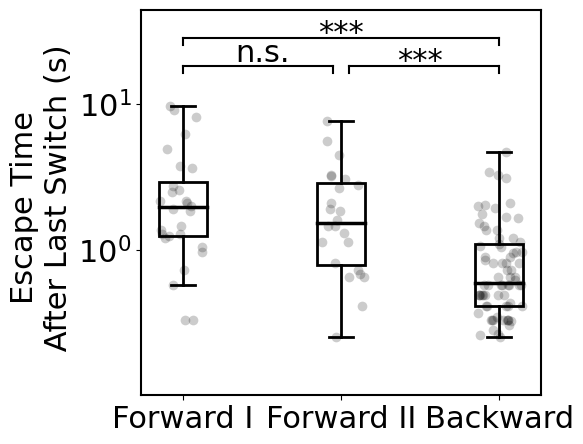

In [16]:
from scipy import stats

# Define line thickness
thickness_axis = 1.5
thickness_box = 1.5
thickness_violin = 2.5
thickness_mean = 1.5
thickness_test = 1.5

key_parameter = 'Escape Time'

# Define box plot colors (minimal palette)
colors = ['#333333', 'dimgray', 'darkgray']

# Create a figure to plot all key parameters
# plt.figure(figsize=(12, 12/390*110))
plt.figure(figsize=(5,5))

# Get the data for each dataset
data_1 = WT_escape_angle_last_switch[WT_escape_angle_last_switch['escape_type'] == 'f_c']['time_since_last_switch'].dropna()
data_2 = WT_escape_angle_last_switch[WT_escape_angle_last_switch['escape_type'] == 'f_s']['time_since_last_switch'].dropna()
data_3 = WT_escape_angle_last_switch[WT_escape_angle_last_switch['escape_type'] == 'b']['time_since_last_switch'].dropna()

# Ensure data are numeric arrays
data_1 = np.array(data_1, dtype=np.float64)
data_2 = np.array(data_2, dtype=np.float64)
data_3 = np.array(data_3, dtype=np.float64)

# log data
data_1 = np.log10(data_1 + 0.01)  # Add a small constant to avoid log(0)
data_2 = np.log10(data_2 + 0.01)  # Add a small constant to avoid log(0)
data_3 = np.log10(data_3 + 0.01)  # Add a small constant to avoid log(0)

# sort data
data_1 = np.sort(data_1)
data_2 = np.sort(data_2)
data_3 = np.sort(data_3)
len_FI = len(data_1)
len_FII = len(data_2)
len_B = len(data_3)
# # remove outliers: > k*std, < k*std
# outlier_k = 2.2
# data_1 = data_1[(data_1 > np.mean(data_1) - outlier_k * np.std(data_1)) & (data_1 < np.mean(data_1) + outlier_k * np.std(data_1))]
# data_2 = data_2[(data_2 > np.mean(data_2) - outlier_k * np.std(data_2)) & (data_2 < np.mean(data_2) + outlier_k * np.std(data_2))]
# data_3 = data_3[(data_3 > np.mean(data_3) - outlier_k * np.std(data_3)) & (data_3 < np.mean(data_3) + outlier_k * np.std(data_3))]

print('before - after removing outliers:')
print(f'FI: {len_FI} - {len(data_1)}')
print(f'FII: {len_FII} - {len(data_2)}')
print(f'B: {len_B} - {len(data_3)}')
# Perform normality test
normality = all([len(data) > 2 and stats.shapiro(data)[1] > 0.05 for data in [data_1, data_2, data_3]])

# Perform overall significance test
if normality:
    overall_stat, overall_p_value = stats.f_oneway(data_1, data_2, data_3)  # ANOVA
    test_name = "ANOVA"
else:
    overall_stat, overall_p_value = stats.kruskal(data_1, data_2, data_3)  # Kruskal-Wallis
    test_name = "Kruskal-Wallis"

def pairwise_test(data1, data2):
    if normality:
        stat, p_value = stats.ttest_ind(data1, data2, equal_var=False)  # Welch's t-test
        stat_symbol = "t"
    else:
        stat, p_value = stats.mannwhitneyu(data1, data2, alternative='two-sided')  # Mann-Whitney U test
        stat_symbol = "U"
    return stat, p_value, stat_symbol

# Compute pairwise statistics and p-values
stat_FI_FII, p_FI_FII, symbol_FI_FII = pairwise_test(data_1, data_2)
stat_FI_B, p_FI_B, symbol_FI_B = pairwise_test(data_1, data_3)
stat_FII_B, p_FII_B, symbol_FII_B = pairwise_test(data_2, data_3)

# Function to assign significance labels
def significance_label(p_value):
    if p_value < 0.001:
        return "***"
    elif p_value < 0.01:
        return "**"
    elif p_value < 0.05:
        return "*"
    else:
        return "n.s."

# Generate significance labels
sig_FI_FII = significance_label(p_FI_FII)
sig_FI_B = significance_label(p_FI_B)
sig_FII_B = significance_label(p_FII_B)

# # Create box plot
# bp = plt.boxplot([data_1, data_2, data_3], vert=True, patch_artist=True, widths=0.5, 
#                     medianprops={'color': 'black', 'linewidth': thickness_mean},
#                     boxprops=dict(linewidth=thickness_box), whiskerprops=dict(linewidth=thickness_axis),
#                     capprops=dict(linewidth=thickness_axis))

# # Set box colors
# for patch, color in zip(bp['boxes'], colors):
#     patch.set_facecolor(color)

# Palette
palette = {
    'Forward I': 'white',
    'Forward II': 'white',
    'Backward': 'white'
}

# Prepare DataFrame
df = pd.DataFrame({
    'value': np.concatenate([data_1, data_2, data_3]),
    'group': ['Forward I'] * len(data_1) + ['Forward II'] * len(data_2) + ['Backward'] * len(data_3)
})

group_order = ['Forward I', 'Forward II', 'Backward']

# Group the data for boxplot
data_ordered = [df[df['group'] == group]['value'].values for group in group_order]

ax = plt.gca()
bp = ax.boxplot(
    data_ordered,
    positions=range(len(group_order)),
    widths=0.3,
    patch_artist=True,
    boxprops=dict(facecolor='none', edgecolor='k', linewidth=2, alpha=1),
    whiskerprops=dict(color='k', linewidth=2, alpha = 1),
    capprops=dict(color='k', linewidth=2, alpha = 1),
    medianprops=dict(color='k', linewidth=2.5, alpha=1),
    flierprops=dict(marker='o', markersize=0)
)

# bp = ax.boxplot(
#     data_ordered,
#     positions=range(len(group_order)),
#     widths=0.3,
#     patch_artist=True,
#     boxprops=dict(facecolor='none', edgecolor='k', linewidth=2, alpha=0.4),
#     whiskerprops=dict(color='k', linewidth=2, alpha = 0.4),
#     capprops=dict(color='k', linewidth=2, alpha = 0.4),
#     medianprops=dict(color='k', linewidth=2.5, alpha=0),
#     flierprops=dict(marker='o', markersize=0)
# )


# # Violin plot with box inside
# sns.violinplot(data=df, x='group', y='value', palette=palette, order=group_order,
#                inner='box', cut=0.7, linewidth=thickness_violin)


# Strip plot
# fix random seed for reproducibility
np.random.seed(3)
# sns.stripplot(data=df, x='group', y='value', order=group_order,
#               color='black', size=4, jitter=0.15, alpha=0.3)
sns.stripplot(data=df, x='group', y='value', order=group_order,
              color='black', size=7, jitter=0.15, alpha=0.2)

# # Overlay median as white circle with black edge
# group_medians = df.groupby('group')['value'].median()
# for i, group in enumerate(group_order):
#     median = group_medians[group]
#     plt.scatter(i, median, color='white', edgecolor='black', s=50, zorder=5)


# Add significance annotations
y_max = np.nanmax([np.nanmax(data_1), np.nanmax(data_2), np.nanmax(data_3)])
# y_line = y_max * 1.15
y_line = y_max*1.275
# vline_height = y_max * 0.005
vline_height = y_max * 0.05

# FI vs. FII
plt.plot([0, 0.95], [y_line, y_line], color='black', linewidth=thickness_axis)  # Short line
plt.plot([0, 0], [y_line, y_line - vline_height], color='black')  # Adjusted vertical line (left)
plt.plot([0.95, 0.95], [y_line, y_line - vline_height], color='black')  # Adjusted vertical line (right)

# FI vs. B
plt.plot([0, 2], [y_line * 1.151, y_line * 1.151], color='black', linewidth=thickness_axis)  # Short line
plt.plot([0, 0], [y_line * 1.151, y_line * 1.151 - vline_height], color='black')  # Adjusted vertical line (left)
plt.plot([2, 2], [y_line * 1.151, y_line * 1.151 - vline_height], color='black')  # Adjusted vertical line (right)

# FII vs. B
plt.plot([1.05, 2], [y_line * 1, y_line * 1], color='black', linewidth=thickness_axis)  # Short line
plt.plot([1.05, 1.05], [y_line * 1, y_line * 1 - vline_height], color='black')  # Adjusted vertical line (left)
plt.plot([2, 2], [y_line * 1, y_line * 1 - vline_height], color='black')  # Adjusted vertical line (right)

# Add significance labels
# -y_max*0.005 if "n.s."
# -y_max*0.01 if "*" or "**" or "***"
# plt.text(0.5, y_line * 1 - y_max*0.005, sig_FI_FII, ha='center', va='bottom', fontsize=12, color='black')  # Text color black
# plt.text(1, y_line * 1.151 - y_max*0.05, sig_FI_B, ha='center', va='bottom', fontsize=12, color='black')  # Text color black
# plt.text(1.5, y_line * 1 - y_max*0.05, sig_FII_B, ha='center', va='bottom', fontsize=12, color='black')  # Text color black

# --v4.7 font--
plt.text(0.5, y_line * 1 - y_max*0.015, sig_FI_FII, ha='center', va='bottom', fontsize=12, color='black')  # Text color black
plt.text(1, y_line * 1.151 - y_max*0.07, sig_FI_B, ha='center', va='bottom', fontsize=12, color='black')  # Text color black
plt.text(1.5, y_line * 1 - y_max*0.07, sig_FII_B, ha='center', va='bottom', fontsize=12, color='black')  # Text color black


# Set labels
# plt.title(f'{key_parameter}')
print(f'{key_parameter}')
plt.xticks([0, 1, 2], [f'Forward I', f'Forward II', f'Backward'])
# plt.ylabel(f'{key_parameter}')
plt.ylabel('Escape Time \n After Last Switch (s)')
plt.xlabel('')
# log y
# plt.yscale('log')

# ylim
plt.ylim(-1, 1.65)
# set y ticks as log scale
# plt.yticks([-1, 0, 1], [r'$10^{-1}$', r'$10^{0}$', r'$10^{1}$'])
plt.yticks([0, 1], [r'$10^{0}$', r'$10^{1}$'])
# Print statistical results
print(f'Pairwise comparisons:')
print(f'  FI vs. FII p-value: {p_FI_FII:.3e}  Significance: {sig_FI_FII}')
print(f'  FI vs. B p-value: {p_FI_B:.3e}  Significance: {sig_FI_B}')
print(f'  FII vs. B p-value: {p_FII_B:.3e}  Significance: {sig_FII_B}')

# ---Parameters---
ax = plt.gca()
# Font sizes
ax.tick_params(axis='both', which='major', labelsize=18)  # Tick label size

# Get the current content of the labels and title
xlabel = ax.get_xlabel()
ylabel = ax.get_ylabel()
title = ax.get_title()

# Set the font sizes without changing the content
ax.set_xlabel(xlabel, fontsize=18)  # X-axis label size
ax.set_ylabel(ylabel, fontsize=18)  # Y-axis label size
ax.set_title(title, fontsize=18)  # Title size

# Set legend size (if you have a legend)
legend = ax.get_legend()
if legend:
    for label in legend.get_texts():
        label.set_fontsize(14)

# Set text size for any additional annotations
for text in ax.texts:
    text.set_fontsize(18)

# Make axes thicker
for spine in ['top', 'right', 'bottom', 'left']:
    ax.spines[spine].set_linewidth(1.5)

# Reduce num of ticks
# ax.locator_params(axis='y', nbins=3)
# ax.locator_params(axis='x', nbins=6)

# Set x tick label font
ax.tick_params(axis='x', which='major', labelsize=18)

# Print statistical summary for publication
print("\nSummary for publication:")
print(f"Statistical analysis was performed to compare differences in {key_parameter}.")
print("Normality was assessed using the Shapiro-Wilk test.")
if normality:
    print(f"Since the data followed a normal distribution (p > 0.05), ANOVA was used.")
    print(f"A {test_name} test revealed a significant difference across groups (F(2, N) = {overall_stat:.3f}, p = {overall_p_value:.3e}).")
else:
    print(f"Since the data did not follow a normal distribution (p < 0.05), a non-parametric approach was used.")
    print(f"A {test_name} test revealed a significant difference across groups ({test_name}(2) = {overall_stat:.3f}, p = {overall_p_value:.3e}).")

print("Pairwise comparisons were conducted using:")
if normality:
    print("Welch’s t-test with a significance level of α = 0.05.")
else:
    print("Mann-Whitney U test with a significance level of α = 0.05.")

print(f"Pairwise test results:")
print(f"  FI vs. B: {symbol_FI_B} = {stat_FI_B:.3f}, p = {p_FI_B:.3e}, {sig_FI_B}")
print(f"  FII vs. B: {symbol_FII_B} = {stat_FII_B:.3f}, p = {p_FII_B:.3e}, {sig_FII_B}")
print(f"  FI vs. FII: {symbol_FI_FII} = {stat_FI_FII:.3f}, p = {p_FI_FII:.3e}, {sig_FI_FII}")

# ---set box size---
def set_size(w,h, ax=None):
    """ w, h: width, height in inches """
    if not ax: ax=plt.gca()
    l = ax.figure.subplotpars.left
    r = ax.figure.subplotpars.right
    t = ax.figure.subplotpars.top
    b = ax.figure.subplotpars.bottom
    figw = float(w)/(r-l)
    figh = float(h)/(t-b)
    ax.figure.set_size_inches(figw, figh)

# set_size(4, 4)
set_size(4, 3.853)

# --v4.7 font--
ax.tick_params(axis='both', which='major', labelsize=22)  # Tick label size
for text in ax.texts:
    text.set_fontsize(22)
if legend:
    for label in legend.get_texts():
        label.set_fontsize(14)
ax.set_ylabel(ylabel, fontsize=22)  # Y-axis label size

# Save figure as PNG (optional), transparent background, tight bounding box
# plt.savefig('{}-box+strip.png'.format(key_parameter), format='png', dpi=900, transparent=True, bbox_inches='tight')
# plt.savefig('{}-box+strip_large_dot_v4.8.png'.format(key_parameter), format='png', dpi=900, transparent=True, bbox_inches='tight')
